# TME ML Non supervisé

In [1]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# K-Means et clustering Géographique

## 1- Data preparation

<div class="alert alert-block alert-info">
Pour cette partie, nous allons reprendre les données des points d'intérêts (POI) de Paris. L'objectif est de caractériser spatialement l'espace urbain parisien en fonction des POIs présents dans une région. Le clustering des régions permet ainsi de mettre en évidence les régions similaires et les raisons de leur similarité (en analysant le prototype de chaque cluster).
    
Les lignes suivantes permettent de dessiner les arrondissements parisien à partir du fichier <code>districts-paris.csv</code> et le charger les POIs (fichier <code>poi-paris.csv</code>)
</div>

In [2]:
table_poi = pd.read_csv('data/poi-paris.csv')
districts=pd.read_csv('data/districts-paris.csv', sep = ',')
districts['bounds'] = districts['bounds'].apply(eval)
#  Draw the districts
def draw_districts():
    for x in districts['bounds']:
        plt.plot([c[0] for c in x], [c[1] for c in x], color = 'black')

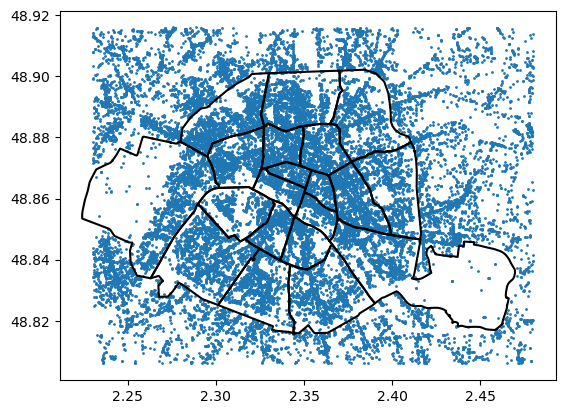

In [3]:
plt.scatter(table_poi["longitude"],table_poi['latitude'],s=1)
draw_districts()

### 2 - Discrétisation manuelle de l'espace

<div class="alert alert-block alert-info">
On ne peut pas utiliser la discrétisation naturelle des arrondissements car celle-ci est trop grande et regroupe des sous-régions de type très différent. Une première façon d'obtenir des sous-régions intéressantes dans Paris est de faire une discrétisation en grille, manuelle. On supposera la grille régulière de taille $N$.

On a donc besoin de connaître pour une coordonnée GPS $(long,lat)$ quelle est la cellule $(i,j)$ de la grille correspondante. Pour une grille de taille $N\times N$, la formule est la suivante : $i=\lfloor N*\frac{(longitude-lomin)}{(lomax-lomin)}\rfloor$ and $j = \lfloor N*\frac{(latitude - lamin)}{(lamax-lamin)} \rfloor$ , avec $\lfloor x\rfloor$ la partie entière de $x$, $lamin,lamax$ les latitudes minimale et maximale, $lomin,lomax$ les longitudes  minimales et maximales.

Chaque cellule de la grille sera décrite par la distribution des types des POIs présents dans l'espace correspondant à la cellule. Il y a 12 types de POIs, ainsi chaque cellule est décrit par un vecteur de dimension 12, donc chaque dimension indique la probabilité du type associé à la dimension dans la région. 
    
Calculez la description associée à chaque cellule. 

Executez un k-means dessus (en utilisant <code>KMeans</code> de scikit-learn, <code>n_clusters</code> permet de fixer le nombre de cluster, la méthode <code>fit()</code> permet de réaliser le clustering, la méthode <code>predict()</code> d'obtenir le cluster associé à chaque exemple, la méthode <code>fit_predict()</code> de faire les deux en même temps).

Visualisez également les centroïdes des clusters. Faites varier le nombre de clusters et comparez les résultats.

Le code suivant permet de représenter graphiquement le clustering calculé (avec <code>get_clust(i,j)</code> renvoyant le numéro du cluster associé à la cellule $(i,j)$) et de tracer les centroïdes (d'un KMeans stocké dans la variable <code>km</code>).


In [4]:
table_poi.keys()

Index(['name', 'latitude', 'longitude', 'note', 'price', 'furniture_store',
       'laundry', 'bakery', 'cafe', 'home_goods_store', 'clothing_store',
       'atm', 'lodging', 'night_club', 'convenience_store', 'restaurant',
       'bar'],
      dtype='object')

In [21]:
N=10

In [8]:
table_poi["longitude"].shape
table_poi["latitude"].shape

(31852,)

In [ ]:
lomin=table_poi["longitude"].min()+1e-6
lomax=table_poi["longitude"].max()+1e-6
lamin=table_poi['latitude'].min()+1e-6
lamax=table_poi['latitude'].max()+1e-6

In [35]:
def coord_to_cell(lon,lat,N,lomin=lomin,lomax=lomax,lamin=lamin,lamax=lamax):
    i=np.floor(N*(lon-lomin)/(lomax-lomin))
    j=np.floor(N*(lat-lamin)/(lamax-lamin))
    return int(i), int(j) #min(int(i),N-1), min(int(j),N-1)

In [29]:
x = [(2.25, 48.905), (2.4, 48.905), (2.25, 48.85), (2.4, 48.85)]
for lon, lat in x:
    print(coord_to_cell(lon, lat,2))


(0, 1)
(1, 1)
(0, 0)
(1, 0)


In [ ]:
# categories= ['furniture_store',
#        'laundry', 'bakery', 'cafe', 'home_goods_store', 'clothing_store',
#        'atm', 'lodging', 'night_club', 'convenience_store', 'restaurant',
#        'bar']

In [18]:
categories = table_poi.columns[5:].tolist()
print(categories)

['furniture_store', 'laundry', 'bakery', 'cafe', 'home_goods_store', 'clothing_store', 'atm', 'lodging', 'night_club', 'convenience_store', 'restaurant', 'bar']


In [50]:
for idx,r in table_poi.iterrows():
    lon=r['longitude']
    lat=r['latitude']
    ii,jj=coord_to_cell(lon,lat,N,lomin=lomin,lomax=lomax,lamin=lamin,lamax=lamax)
    # if ii >= N or jj >= N:
    #     print(ii, jj)
    #     print("ERROR")
    #     break
    
    if ii == N or jj == N:
        print(ii, jj)

10 9
2 10


In [33]:
grille=np.zeros((N,N,len(categories)))
for idx,r in table_poi.iterrows():
    lon=r['longitude']
    lat=r['latitude']
    ii,jj=coord_to_cell(lon,lat,N,lomin=lomin,lomax=lomax,lamin=lamin,lamax=lamax)
    for k, c in enumerate(categories): 
        grille[ii, jj, k] += r[c]
    

In [39]:
X=grille.reshape(-1,len(categories))

In [40]:
km=KMeans(n_clusters=len(categories),verbose=1,random_state=42)

In [41]:
labels = km.fit_predict(X)

Initialization complete
Iteration 0, inertia 164832.0.
Iteration 1, inertia 120860.61705484142.
Iteration 2, inertia 114641.57777195137.
Iteration 3, inertia 113101.04630302815.
Iteration 4, inertia 112151.40835023517.
Iteration 5, inertia 111787.83309099432.
Iteration 6, inertia 111502.44894266466.
Iteration 7, inertia 111145.91234517422.
Iteration 8, inertia 110740.200166348.
Iteration 9, inertia 110524.73324267445.
Iteration 10, inertia 110391.64633901174.
Iteration 11, inertia 110260.03993347344.
Iteration 12, inertia 110204.13226297704.
Iteration 13, inertia 110179.24201680259.
Iteration 14, inertia 110053.98580187559.
Converged at iteration 14: strict convergence.


In [42]:
table_poi.keys()

Index(['name', 'latitude', 'longitude', 'note', 'price', 'furniture_store',
       'laundry', 'bakery', 'cafe', 'home_goods_store', 'clothing_store',
       'atm', 'lodging', 'night_club', 'convenience_store', 'restaurant',
       'bar'],
      dtype='object')

In [43]:
labels_grid=labels.reshape(N,N)

In [44]:
def get_clust(i, j):
    return labels_grid[i, j]


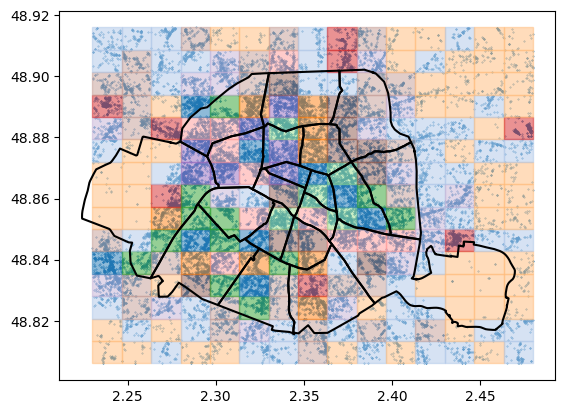

In [45]:
from matplotlib.patches import Rectangle
from matplotlib.cm import tab20
_ = plt.scatter(table_poi["longitude"],table_poi['latitude'],s=0.1)
draw_districts()
for i in range(N):
    for j in range(N):
        x = lomin + (lomax - lomin) * i / N
        y = lamin + (lamax - lamin) * j / N
        c = tab20.colors[get_clust(i,j)]
        _ = plt.gca().add_patch(Rectangle((x, y), (lomax - lomin) / N, (lamax - lamin) / N, color = c, alpha = 0.5))


In [46]:
types=categories

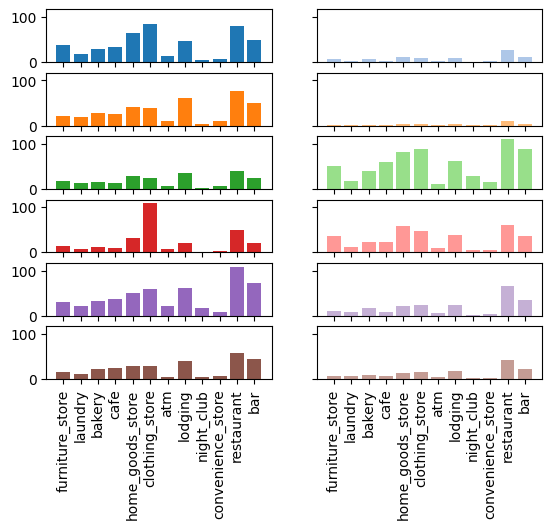

In [47]:
fig, axs = plt.subplots(len(km.cluster_centers_)//2, 2, sharey=True,sharex=True)
for i,k in enumerate(km.cluster_centers_):
    axs.flatten()[i].bar(range(len(k)),k,color=tab20.colors[i])
    axs.flatten()[i].set_xticks(range(len(k)))
    axs.flatten()[i].set_xticklabels(types,rotation="vertical")

<div class="alert alert-block alert-info">
Le score elbow du  modèle correspond à l'attribut <em>inertia_</em> du modèle. Dessinez la courbe elbow en fonction du nombre de clusters. Quel est le nombre optimal de clusters d'après cette courbe ?
    </div>

## 3 -  K-Means pour la discrétisation automatique de l'espace

<div class="alert alert-block alert-info">
    Pour obtenir des clusters plus pertinents, la discrétisation de l'espace doit être faite de manière moins naïve. Une idée est d'utiliser églament l'algorithme  $K$-means pour cela, en clusterisant les coordonnées GPS des POIs (ce qui est également appelé une <em>quantization</em>). 
    </br>
    Calculez ce clustering spatial et attribuez à chaque POI un numéro de cluster spatial (n.b. une grille de taille $10\times 10$ est "équivalente" à avoir 100 clusters).
    
Représentez graphiquement les clusters ainsi trouvés à l'aide des lignes de codes suivantes (<code>get_cluster_spatial(i)</code> rend le cluster du $i$-ème POI, le modèle KMeans est stocké dans la variable <code>km_spatial</code>).

Effectuez le clustering sur cette nouvelle discrétisation et comparez vos résultats.

Observez la corrélation entre les types sur les données initiales. Pouvez vous proposer un traitement pour améliorer les résultats ?
</div>

(225,)


In [ ]:
def get_cluster_spatial(i):
    pass

IndexError: index 225 is out of bounds for axis 0 with size 225

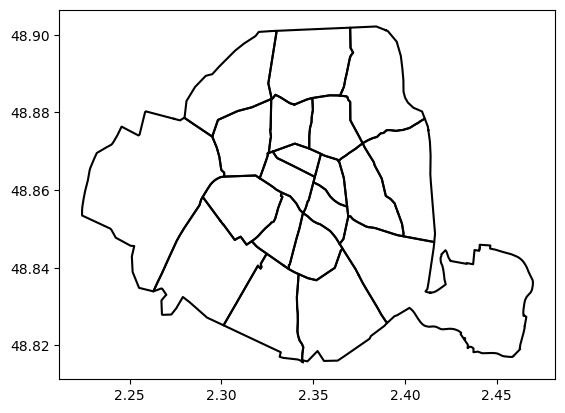

In [58]:
draw_districts()
plt.scatter(np.array(table_poi['longitude'],dtype=int),np.array(table_poi['latitude'],dtype=int),color = [tab20.colors[get_cluster_spatial(i) % 20] for i in range(len(table_poi))], s = 0.5)
for i in range(K_GEO):
    plt.plot(km_spatial.cluster_centers_[i, 0], km_spatial.cluster_centers_[i, 1], marker = "*", color = "black", markersize = 5)